# eQTL preprocessing cont. + analysis

In [63]:
import pandas as pd
import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
import random
import re

## Loading data

Loading expression from HDF5:

In [78]:
with h5py.File('data/preprocessed/geuvadis_sv_expr.h5', 'r') as f:
    def print_structure(name, obj):
        print(name)
    f.visititems(print_structure)

expr_genes
expression
samples
sv_gt
sv_ids


In [79]:
with h5py.File('data/preprocessed/geuvadis_sv_expr.h5', 'r') as h5:
    expr_matrix = h5['expression'][:]
    genes = [g.decode() if hasattr(g, 'decode') else g for g in h5['expr_genes'][:]]
    samples = [s.decode() if hasattr(s, 'decode') else s for s in h5['samples'][:]]

expr = pd.DataFrame(expr_matrix, index=samples, columns=genes).T
print(expr.shape)
print(expr.head())


(18870, 28)
                     HG00096    HG00097    HG00099    HG00100    HG00101  \
ENSG00000227232.4   4.323780   3.602970   3.631219   3.781200   4.297581   
ENSG00000237683.5   2.043834   1.812976   0.852204   1.226079   2.959925   
ENSG00000239906.1   1.083229   0.900620   0.339549   0.226199   1.592981   
ENSG00000225972.1  11.774630  11.614216  11.197738  11.684908  11.885773   
ENSG00000225630.1  11.894153  12.178942  11.397673  11.884973  12.131914   

                     HG00102    HG00103    HG00105    HG00106    HG00108  ...  \
ENSG00000227232.4   3.182880   4.154123   3.940888   4.343156   4.147351  ...   
ENSG00000237683.5   2.267890   1.849592   1.095066   1.874517   2.398478  ...   
ENSG00000239906.1   1.586163   1.015464   0.000000   0.641311   1.539910  ...   
ENSG00000225972.1  12.628022  12.027189  12.335571  11.572188  12.520845  ...   
ENSG00000225630.1  12.705209  11.994469  12.346259  11.774931  12.580176  ...   

                     HG00118    HG00119    H

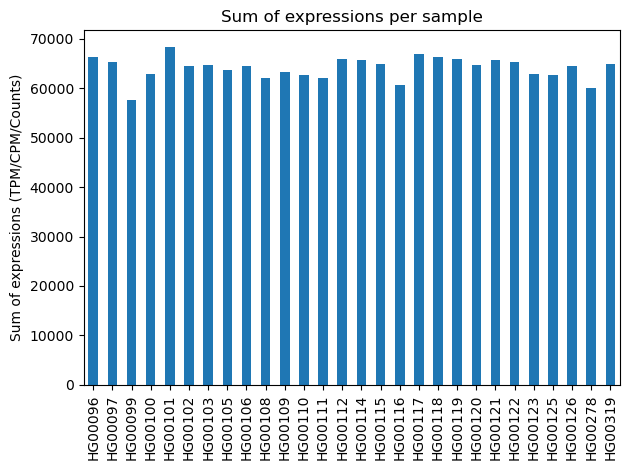

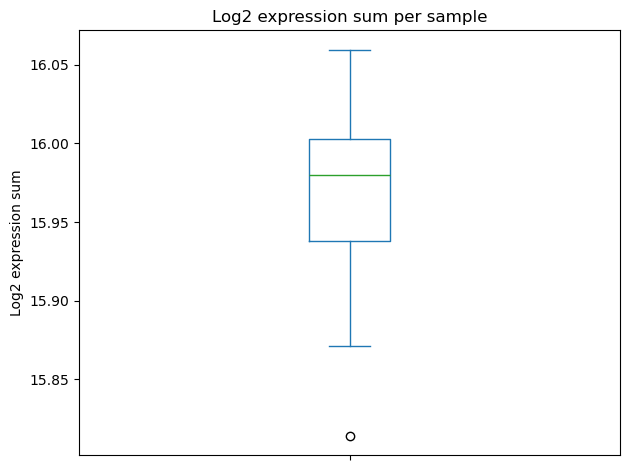

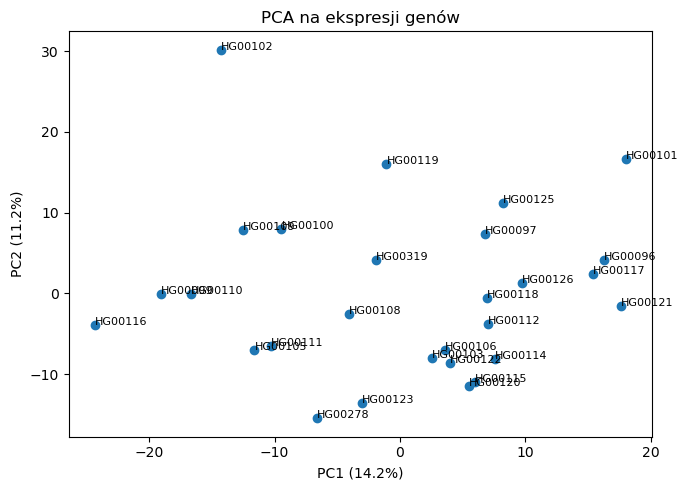

/home/klosa/miniconda3/envs/sveqtl/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/klosa/miniconda3/envs/sveqtl/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


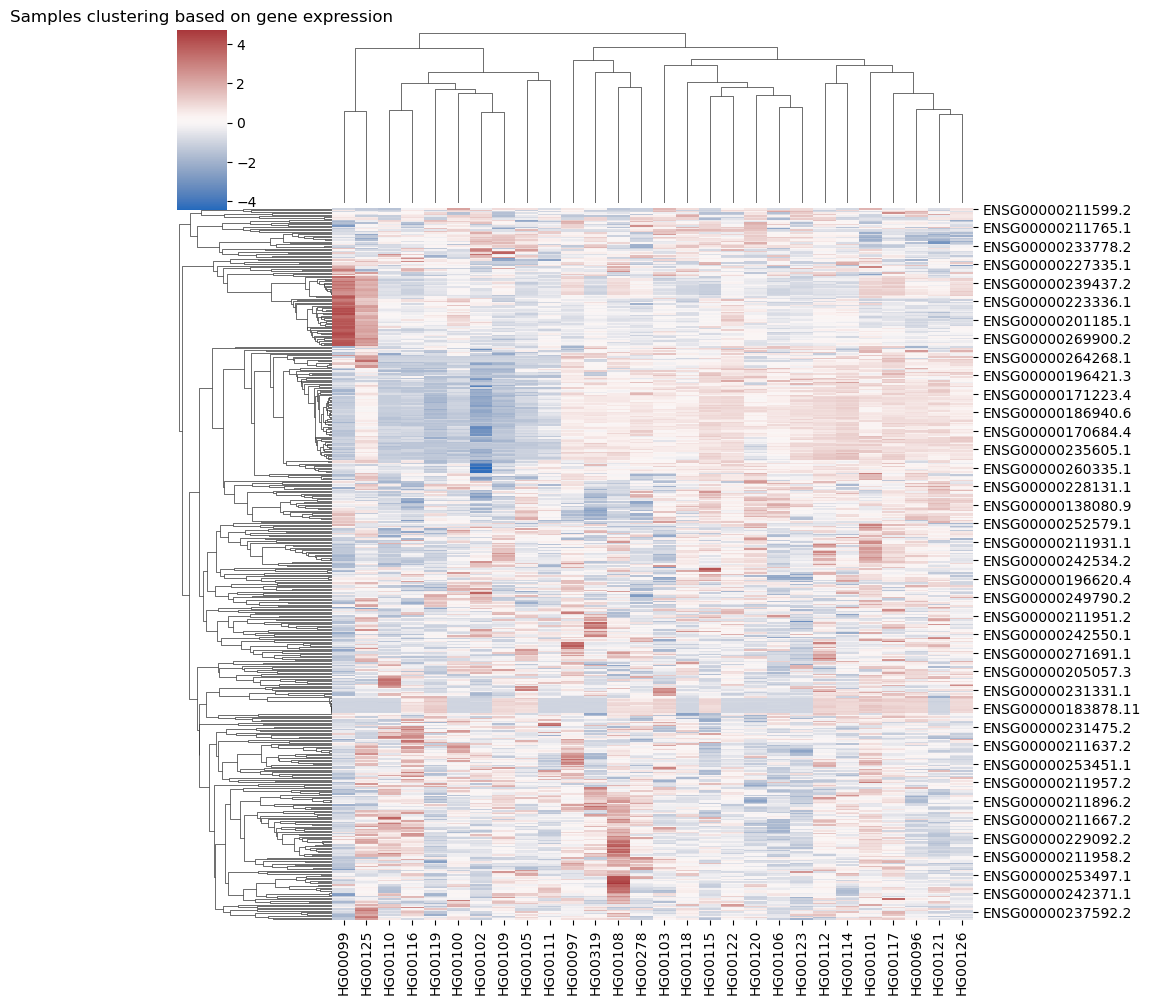

In [ ]:
# sum of expressions per sample -- looking for outliers
df_expr.sum(axis=0).plot(kind='bar', title='Sum of expressions per sample')
plt.ylabel("Sum of expressions (TPM/CPM/Counts)")
plt.tight_layout()
plt.show()

# log2(sum) distribution
np.log2(df_expr.sum(axis=0) + 1).plot(kind='box', title='Log2 expression sum per sample')
plt.ylabel("Log2 expression sum")
plt.tight_layout()
plt.show()

# PCA on expression data
expr_log = np.log2(df_expr + 1)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(expr_log.T)  # transpose as samples in columns
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
for i, sample in enumerate(df_expr.columns):
    plt.text(X_pca[i,0], X_pca[i,1], sample, fontsize=8)
plt.xlabel('PC1 (%.1f%%)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%%)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA na ekspresji genów')
plt.tight_layout()
plt.show()

# clustermap (top 500 genes)
top_genes = df_expr.var(axis=1).sort_values(ascending=False).index[:500]
sns.clustermap(df_expr.loc[top_genes], metric="correlation", z_score=0, cmap='vlag')
plt.title('Samples clustering based on gene expression')
plt.show()


Loading SV genotypes:

In [ ]:
geno = pd.read_csv('data/1kg_sv/genotypes_numeric.txt', sep='\t', index_col=0)
print(geno.shape)
print(geno.iloc[10:, :5])

(12321, 445)
                              HG00096  HG00097  HG00099  HG00100  HG00101
ID                                                                       
BI_GS_DEL1_B5_P0002_270           0.0      0.0      0.0      0.0      0.0
YL_CN_YRI_28                      0.0      0.0      0.0      0.0      0.0
DUP_gs_CNV_1_1627805_1673809      0.0      0.0      0.0      0.0      0.0
BI_GS_DEL1_B5_P0002_358           0.0      0.0      0.0      0.0      0.0
UW_VH_14735                       0.0      0.0      0.0      0.0      0.0
...                               ...      ...      ...      ...      ...
YL_CN_IBS_4183                    NaN      2.0      2.0      1.0      NaN
DEL_pindel_54962                  NaN      1.0      1.0      1.0      NaN
UW_VH_1324                        NaN      0.0      0.0      1.0      NaN
L1_umary_LINE1_3150               0.0      0.0      0.0      1.0      0.0
UW_VH_7995                        NaN      0.0      0.0      0.0      NaN

[12311 rows x 5 columns]

Checking shared samples:

In [76]:
shared_samples = sorted(list(set(expr.columns) & set(geno.columns)))
expr_sync = expr[shared_samples]
geno_sync = geno[shared_samples]

print(f"Number of common samples: {len(shared_samples)}")
print("Example of common samples:", shared_samples[:5])
print("The shape of expression matrix:", expr_sync.shape)
print("The shape of the genotype matrix:", geno_sync.shape)

# checking if the order of samples is the same
assert all(expr_sync.columns == geno_sync.columns), "Kolejność próbek nie jest zgodna!"

Number of common samples: 28
Example of common samples: ['HG00096', 'HG00097', 'HG00099', 'HG00100', 'HG00101']
The shape of expression matrix: (18870, 28)
The shape of the genotype matrix: (12321, 28)


## Data synchronization

We only perform further analysis on those samples that appear in both the expression and the SV genotype matrix as this ensures that each column corresponds to the same individual in both matrices:

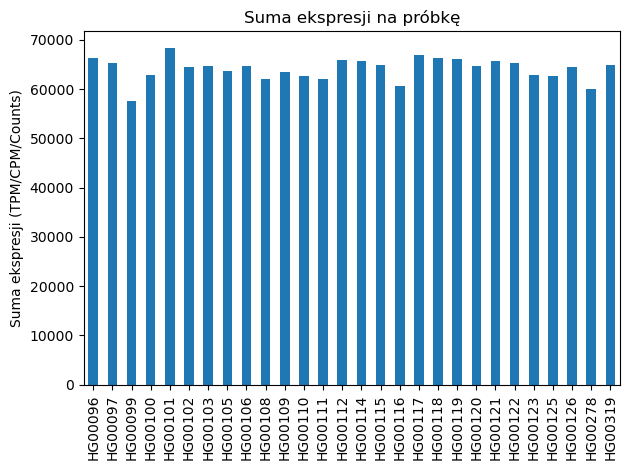

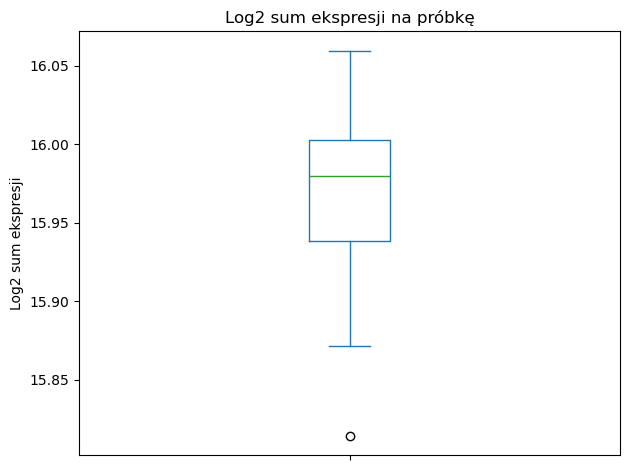

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Suma ekspresji na próbkę (prosty outlier check)
df_expr.sum(axis=1).plot(kind='bar', title='Suma ekspresji na próbkę')
plt.ylabel("Suma ekspresji (TPM/CPM/Counts)")
plt.tight_layout()
plt.show()

# Rozkład log2(sum) (często użyteczny)
np.log2(df_expr.sum(axis=1) + 1).plot(kind='box', title='Log2 sum ekspresji na próbkę')
plt.ylabel("Log2 sum ekspresji")
plt.tight_layout()
plt.show()


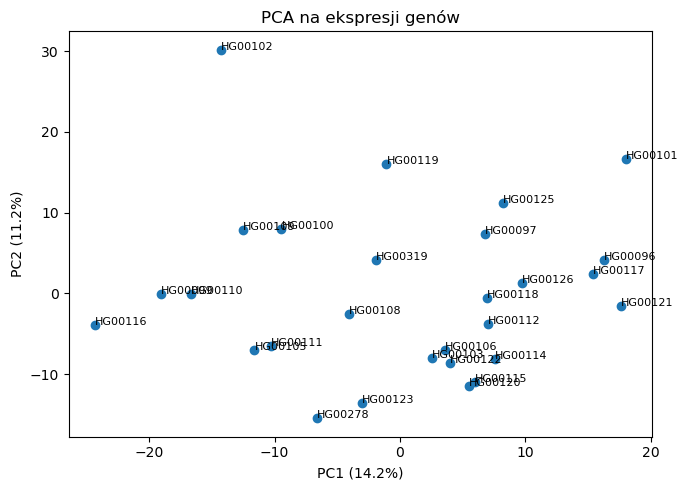

In [5]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Załóżmy, że masz już df_expr
# Wstępna normalizacja i filtracja (jeśli nie zrobiłeś tego wcześniej)
expr_log = np.log2(df_expr + 1)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(expr_log)

plt.figure(figsize=(7,5))
plt.scatter(X_pca[:,0], X_pca[:,1])
for i, sample in enumerate(df_expr.index):
    plt.text(X_pca[i,0], X_pca[i,1], sample, fontsize=8)
plt.xlabel('PC1 (%.1f%%)' % (pca.explained_variance_ratio_[0]*100))
plt.ylabel('PC2 (%.1f%%)' % (pca.explained_variance_ratio_[1]*100))
plt.title('PCA na ekspresji genów')
plt.tight_layout()
plt.show()


/home/klosa/miniconda3/envs/sveqtl/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/klosa/miniconda3/envs/sveqtl/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


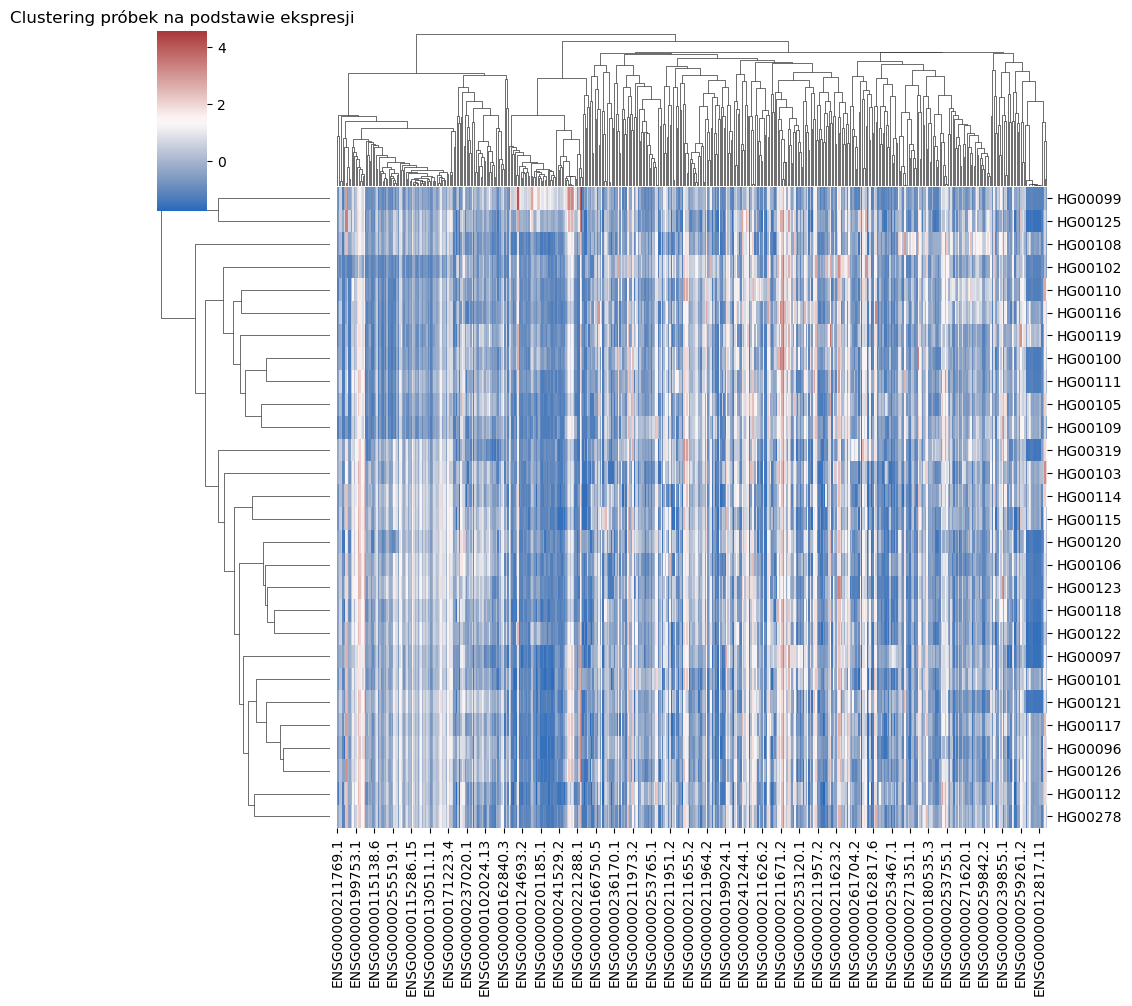

In [6]:
import seaborn as sns

# Wybierz top 500 najbardziej zmiennych genów do clustermap (przyspiesza)
top_genes = df_expr.var(axis=0).sort_values(ascending=False).index[:500]
sns.clustermap(df_expr[top_genes], metric="correlation", z_score=0, cmap='vlag')
plt.title('Clustering próbek na podstawie ekspresji')
plt.show()


 SV-gene single association test (checking if a sample has correct results):

In [ ]:
import statsmodels.api as sm

sv_id = geno_sync.index[0]     # first SV
gene_id = expr_sync.index[0]   # first gene

X = geno_sync.loc[sv_id].astype(float)
y = expr_sync.loc[gene_id].astype(float)

print(X.shape, y.shape)

# linear regression
X_design = sm.add_constant(X)
model = sm.OLS(y, X_design)
results = model.fit()
print(results.summary())

(28,) (28,)
                            OLS Regression Results                            
Dep. Variable:      ENSG00000227232.4   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     1.744
Date:                Tue, 03 Jun 2025   Prob (F-statistic):              0.198
Time:                        20:26:50   Log-Likelihood:                -10.855
No. Observations:                  28   AIC:                             25.71
Df Residuals:                      26   BIC:                             28.37
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1672    

SV–gen regression test (small subset per sample):

In [91]:
results_list = []

for sv_id in geno_sync.index[:10]:     
    X = geno_sync.loc[sv_id].astype(float)
    for gene_id in expr_sync.index[:10]:
        y = expr_sync.loc[gene_id].astype(float)
        mask = (~X.isna()) & (~y.isna())
        if mask.sum() < 10: continue
        X_design = sm.add_constant(X[mask])
        y_sub = y[mask]
        fit = sm.OLS(y_sub, X_design).fit()
        if len(fit.pvalues) < 2: continue
        results_list.append({
            'sv': sv_id,
            'gene': gene_id,
            'pvalue': fit.pvalues[sv_id],
            'beta': fit.params[sv_id],
            'n': mask.sum()})


df_results = pd.DataFrame(results_list)
df_results['FDR'] = multipletests(df_results['pvalue'], method='fdr_bh')[1]
print(df_results.sort_values('pvalue').head())


                  sv               gene    pvalue      beta   n  FDR
32     DEL_pindel_11  ENSG00000239906.1  0.022402  0.844479  28  NaN
31     DEL_pindel_11  ENSG00000237683.5  0.036140  0.811861  28  NaN
50        UW_VH_1989  ENSG00000227232.4  0.071629  0.332383  28  NaN
13  L1_umary_LINE1_1  ENSG00000225972.1  0.078698  0.911643  28  NaN
63     DEL_pindel_17  ENSG00000225972.1  0.078698  0.911643  28  NaN


"Top hits" visualization:

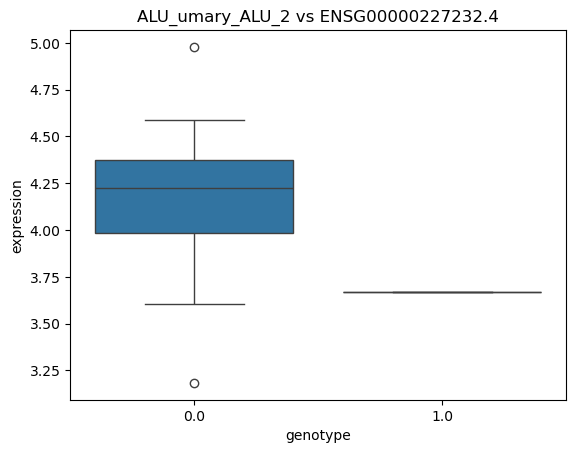

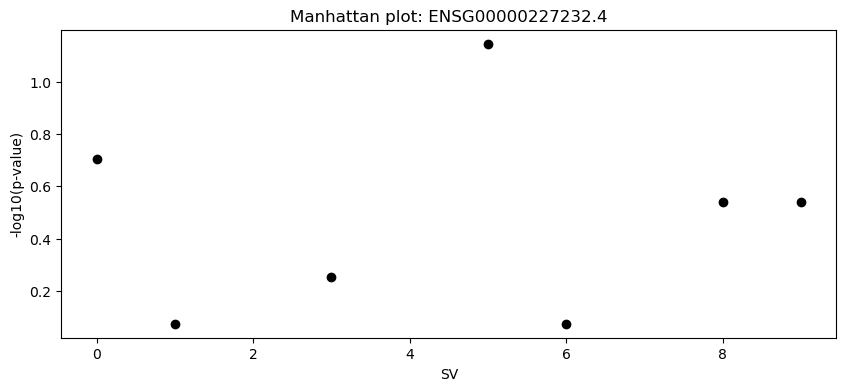

In [ ]:
# boxplot of top gene
top = df_results.sort_values('FDR').iloc[0]
sv = top['sv']
gene = top['gene']
df_plot = pd.DataFrame({'genotype': geno_sync.loc[sv], 'expression': expr_sync.loc[gene]})
sns.boxplot(x='genotype', y='expression', data=df_plot)
plt.title(f'{sv} vs {gene}')
plt.show()

# Manhattan plot for one top gene 
selected_gene = top['gene']
df_gene = df_results[df_results['gene'] == selected_gene]
plt.figure(figsize=(10, 4))
plt.scatter(range(len(df_gene)), -np.log10(df_gene['pvalue']), c='black')
plt.xlabel('SV')
plt.ylabel('-log10(p-value)')
plt.title(f'Manhattan plot: {selected_gene}')
plt.show()

Annotations (SV/gene positions, cis-pairs):

In [ ]:
# loading SV from VCF
vcf_path = 'data/1kg_sv/sv_geuvadis_only.vcf.gz'
vcf_sv = pd.read_csv(
    vcf_path,
    sep='\t',
    comment='#',
    header=None,
    usecols=[0,1,2,7],
    names=['CHROM', 'POS', 'ID', 'INFO'],
    dtype={'CHROM': str, 'POS': int, 'ID': str, 'INFO': str}
)

def get_end(info): m = re.search(r'END=(\d+)', info); return int(m.group(1)) if m else None
vcf_sv['END'] = vcf_sv['INFO'].apply(get_end)
vcf_sv = vcf_sv[['ID', 'CHROM', 'POS', 'END']]
vcf_sv['POS'] = vcf_sv['POS'].astype(int)
vcf_sv['END'] = vcf_sv['END'].fillna(vcf_sv['POS'])
sv_positions = vcf_sv.set_index('ID').T.to_dict()

# loading GTF (genes)
gtf = pd.read_csv('data/reference/gencode.v19.annotation.gtf', sep='\t', comment='#', header=None, names=['chr', 'src', 'feature', 'start', 'end', 'dot', 'strand', 'dot2', 'info'])
gtf_genes = gtf[gtf['feature'] == 'gene']
def get_gene_id(info): m = re.search(r'gene_id "([^"]+)"', info); return m.group(1).split('.')[0] if m else None
gtf_genes['gene_id'] = gtf_genes['info'].apply(get_gene_id)
gene_positions = gtf_genes.set_index('gene_id')[['chr', 'start', 'end']].to_dict(orient='index')

# changing chr to strings to get uniform format
def sv_chr_as_str(chrom):
    chrom = str(chrom)
    if not chrom.startswith('chr'): return 'chr' + chrom
    return chrom
for sv in sv_positions:
    sv_positions[sv]['CHROM'] = sv_chr_as_str(sv_positions[sv]['CHROM'])
for gene in gene_positions:
    if not str(gene_positions[gene]['chr']).startswith('chr'):
        gene_positions[gene]['chr'] = 'chr' + str(gene_positions[gene]['chr'])

# cis-pairs
cis_pairs = []
window = 1_000_000  # 1Mb
for sv_id, sv_pos in sv_positions.items():
    for gene_id, gene_pos in gene_positions.items():
        if sv_pos['CHROM'] == gene_pos['chr']:
            dist = min(abs(sv_pos['POS'] - gene_pos['start']), abs(sv_pos['END'] - gene_pos['end']))
            if dist <= window:
                cis_pairs.append((sv_id, gene_id))
                
print(f'Number of cis-pairs: {len(cis_pairs)}')


/tmp/ipykernel_19909/418014065.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gtf_genes['gene_id'] = gtf_genes['info'].apply(get_gene_id)


Number of cis-pairs: 550457


In [95]:
subset_cis_pairs = cis_pairs[:10000]  # limiting to 10000 pairs for speed
results_list = []
for sv_id, gene_id in subset_cis_pairs:
    if sv_id not in geno_sync.index:
        continue
    expr_gene_id = [g for g in expr_sync.index if g.split('.')[0] == gene_id]
    if not expr_gene_id:
        continue
    expr_gene_id = expr_gene_id[0]
    X = geno_sync.loc[sv_id].astype(float)
    y = expr_sync.loc[expr_gene_id].astype(float)
    mask = (~X.isna()) & (~y.isna())
    if mask.sum() < 10: continue
    X_design = sm.add_constant(X[mask])
    y_sub = y[mask]
    fit = sm.OLS(y_sub, X_design).fit()
    if len(fit.pvalues) < 2: continue
    results_list.append({
    'sv': sv_id,
    'gene': expr_gene_id,
    'pvalue': fit.pvalues.iloc[1],
    'beta': fit.params.iloc[1],
    'n': mask.sum()
})

df_results = pd.DataFrame(results_list)
print(df_results.sort_values('pvalue').head())


                          sv                gene    pvalue      beta   n
1114          DEL_pindel_150  ENSG00000116237.11  0.000703 -1.107464  28
2841  BI_GS_DEL1_B3_P0022_20   ENSG00000187608.5  0.001047  1.025424  28
2858  BI_GS_DEL1_B3_P0022_20  ENSG00000142794.14  0.001070 -0.366812  28
3360          DEL_pindel_373   ENSG00000117748.5  0.001296 -0.234784  28
2120            YL_CN_FIN_64   ENSG00000235084.2  0.001385 -0.413775  28
